#### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import warnings
warnings.filterwarnings('ignore')

import time

#### Import Datasets

In [2]:
%store -r Set1_X_Train
%store -r Set1_X_Test

%store -r Set1_y_Train
%store -r Set1_y_Test

#### Random Forest Regression(All Columns)

In [3]:
start = time.time()

Set1_y_Train_array = Set1_y_Train.values.ravel()
Set1_y_Test_array = Set1_y_Test.values.ravel()

'''
random_forest_reg = RandomForestRegressor(n_estimators=500,
                                          max_features='sqrt',
                                          n_jobs=-1,
                                          random_state=38
                                          ).fit(Set1_X_Train, Set1_y_Train_array)
'''

rf = RandomForestRegressor(n_jobs=-1, random_state=38)

param_grid = {
    "n_estimators": [50, 200, 300, 400, 500],
    "max_features": ["sqrt", "log2"]
}

grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, scoring="neg_root_mean_squared_error", 
                           n_jobs=-1, cv=5)

grid_search.fit(Set1_X_Train, Set1_y_Train_array)
end_grid_search = time.time()

best_params = grid_search.best_params_
print("Best Parameters:", best_params)

random_forest_reg = RandomForestRegressor(n_estimators=best_params['n_estimators'],
                                max_features=best_params['max_features'],
                                n_jobs=-1,
                                random_state=38)

random_forest_reg.fit(Set1_X_Train, Set1_y_Train_array)
end_train = time.time()  

rf_reg_pred_train = random_forest_reg.predict(Set1_X_Train)
end_predict_train = time.time()

rf_reg_pred_test = random_forest_reg.predict(Set1_X_Test)
end_predict_test = time.time()

rf_reg_pred_train_int = rf_reg_pred_train.astype(int)
rf_reg_pred_test_int = rf_reg_pred_test.astype(int)

Best Parameters: {'max_features': 'sqrt', 'n_estimators': 500}


#### Random Forest Evaluation

In [4]:
# Mean Squared Error
mse_train_rf = mean_squared_error(Set1_y_Train_array, rf_reg_pred_train_int)
mse_test_rf = mean_squared_error(Set1_y_Test_array, rf_reg_pred_test_int)

# Root Mean Squared Error
rmse_train_rf = np.sqrt(mse_train_rf)
rmse_test_rf = np.sqrt(mse_test_rf)

# Mean Absolute Error
mae_train_rf = mean_absolute_error(Set1_y_Train_array, rf_reg_pred_train_int)
mae_test_rf = mean_absolute_error(Set1_y_Test_array, rf_reg_pred_test_int)

# R2 Score
r2_train_rf = r2_score(Set1_y_Train_array, rf_reg_pred_train_int)
r2_test_rf = r2_score(Set1_y_Test_array, rf_reg_pred_test_int)

# Time
time_grid_search = end_grid_search - start
fit_time = end_train - end_grid_search
time_predict_train = end_predict_train - end_train
time_predict_test = end_predict_test - end_predict_train
total_time = end_predict_test - start

# Training Set
print("--Training Set Evaluation--")
print("Mean Squared Error:", mse_train_rf)
print("Root Mean Squared Error:", rmse_train_rf)
print("Mean Absolute Error:", mae_train_rf)
print("R-squared Score:", r2_train_rf)

# Testing Set
print("\n--Testing Set Evaluation--")
print("Mean Squared Error:", mse_test_rf)
print("Root Mean Squared Error:", rmse_test_rf)
print("Mean Absolute Error:", mae_test_rf)
print("R-squared Score:", r2_test_rf)

# Time
print("\n--Fit, Training Times--")
print("Time for grid search:", "{:.2f}".format(time_grid_search), "seconds")
print("Time to fit:", "{:.2f}".format(fit_time), "seconds")
print("Time to predict (train set):", "{:.2f}".format(time_predict_train), "seconds")
print("Time to predict (test set):", "{:.2f}".format(time_predict_test), "seconds")
print("Total Time:", "{:.2f}".format(total_time), "seconds")

--Training Set Evaluation--
Mean Squared Error: 230.69613688139208
Root Mean Squared Error: 15.188684501344811
Mean Absolute Error: 10.665115602733751
R-squared Score: 0.9513746645846203

--Testing Set Evaluation--
Mean Squared Error: 1001.61
Root Mean Squared Error: 31.648222698913127
Mean Absolute Error: 22.83
R-squared Score: 0.41998515695684246

--Fit, Training Times--
Time for grid search: 69.50 seconds
Time to fit: 2.73 seconds
Time to predict (train set): 0.28 seconds
Time to predict (test set): 0.05 seconds
Total Time: 72.55 seconds


#### Plot Evaluation Results

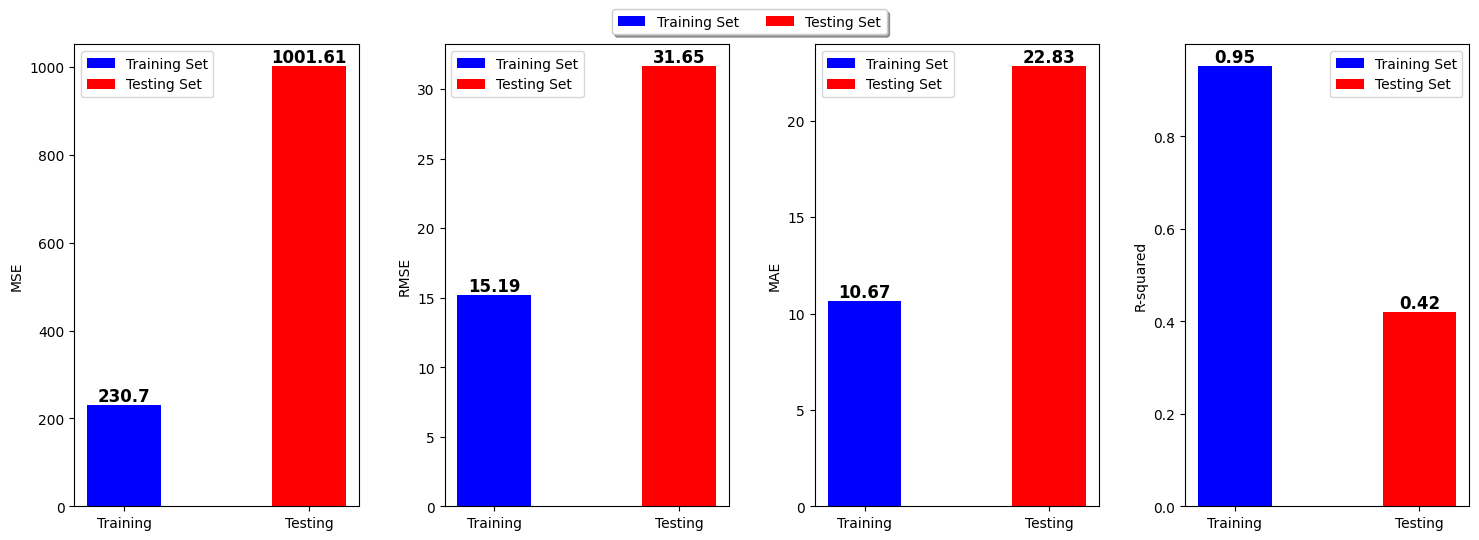

In [5]:
metrics = ['MSE', 'RMSE', 'MAE', 'R-squared', 'COD']
train_metrics = [mse_train_rf, rmse_train_rf, mae_train_rf, r2_train_rf]
test_metrics = [mse_test_rf, rmse_test_rf, mae_test_rf, r2_test_rf]

fig, axes = plt.subplots(1, 4, figsize=(18, 6))

for i, (metric, train_metric, test_metric) in enumerate(zip(metrics, train_metrics, test_metrics)):
    ax = axes[i]
    ax.bar('Training', train_metric, color='b', label='Training Set', width=0.4)
    ax.bar('Testing', test_metric, color='r', label='Testing Set', width=0.4)
    ax.set_ylabel(metric)

    for bar in ax.patches:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, height, round(height, 2), 
                ha='center', va='bottom', fontsize=12, fontweight='bold')

    ax.legend()

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.95), fancybox=True, shadow=True, ncol=2)

plt.subplots_adjust(wspace=0.3)
plt.show()

##### Plot Predicted vs Actual Values

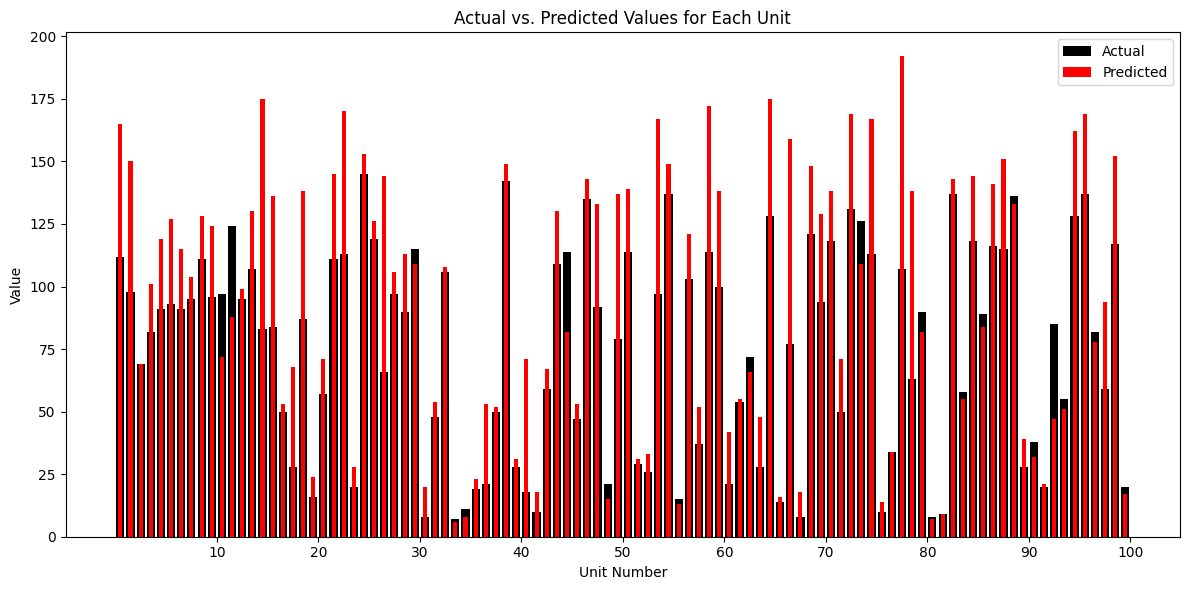

In [6]:
num_units = len(Set1_y_Test)
unit_numbers = np.arange(1, num_units + 1) 

actual_values = np.squeeze(Set1_y_Test)
predicted_values = np.squeeze(rf_reg_pred_test_int)

fig, ax = plt.subplots(figsize=(12, 6))

bar_width = 0.8
spacing = 1

ax.bar(unit_numbers - spacing/2, actual_values, bar_width, label='Actual', color='black')
ax.bar(unit_numbers - spacing/2, predicted_values, bar_width/2, label='Predicted', color='red')

ax.set_xlabel('Unit Number')
ax.set_ylabel('Value')
ax.set_title('Actual vs. Predicted Values for Each Unit')

tick_positions = np.arange(10, num_units + 1, 10)
ax.set_xticks(tick_positions)
ax.set_xticklabels([str(int(t)) for t in tick_positions]) 

ax.legend()
plt.tight_layout()
plt.show()

#### Random Forest Regressor (Dropped Constant, Highly Related Features, Applied Upper RUL Limit)

##### Import Dataset

In [7]:
%store -r FD1_X_Train
%store -r FD1_X_Test

%store -r FD1_y_Train
%store -r FD1_y_Test

#### RF Regressor

In [8]:
start = time.time()

FD1_y_Train_array = FD1_y_Train.values.ravel()
FD1_y_Test_array = FD1_y_Test.values.ravel()

'''
rf_new = RandomForestRegressor(n_estimators=500,
                              max_features='sqrt',
                              n_jobs=-1,
                              random_state=38
                             ).fit(FD1_X_Train,FD1_y_Train_array)

end_train = time.time()
'''

rf = RandomForestRegressor(n_jobs=-1, random_state=38)

param_grid = {
    "n_estimators": [50, 200, 300, 400, 500],
    "max_features": ["sqrt", "log2"]
}

grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, scoring="neg_root_mean_squared_error", 
                           n_jobs=-1, cv=5)

grid_search.fit(FD1_X_Train, FD1_y_Train_array)
end_grid_search = time.time()  

best_params = grid_search.best_params_
print("Best Parameters:", best_params)

rf_new = RandomForestRegressor(n_estimators=best_params['n_estimators'],
                                max_features=best_params['max_features'],
                                n_jobs=-1,
                                random_state=38)

rf_new.fit(FD1_X_Train, FD1_y_Train_array)
end_train = time.time() 

rf_new_pred_train = rf_new.predict(FD1_X_Train)
end_predict_train = time.time()

rf_new_pred_test = rf_new.predict(FD1_X_Test)
end_predict_test = time.time()

Best Parameters: {'max_features': 'sqrt', 'n_estimators': 500}


#### Random Forest Evaluation

In [9]:
# Mean Squared Error
mse_train_rf_new = mean_squared_error(FD1_y_Train_array, rf_new_pred_train)
mse_test_rf_new = mean_squared_error(FD1_y_Test_array, rf_new_pred_test)

# Root Mean Squared Error
rmse_train_rf_new = np.sqrt(mse_train_rf_new)
rmse_test_rf_new = np.sqrt(mse_test_rf_new)

# Mean Absolute Error
mae_train_rf_new = mean_absolute_error(FD1_y_Train_array, rf_new_pred_train)
mae_test_rf_new = mean_absolute_error(FD1_y_Test_array, rf_new_pred_test)

# R2 Score
r2_train_rf_new = r2_score(FD1_y_Train_array, rf_new_pred_train)
r2_test_rf_new = r2_score(FD1_y_Test_array, rf_new_pred_test)

# Time
time_grid_search = end_grid_search - start
fit_time = end_train - end_grid_search
time_predict_train = end_predict_train - end_train
time_predict_test = end_predict_test - end_predict_train
total_time = end_predict_test - start

# Training Set
print("--Training Set Evaluation--")
print("Mean Squared Error:", mse_train_rf_new)
print("Root Mean Squared Error:", rmse_train_rf_new)
print("Mean Absolute Error:", mae_train_rf_new)
print("R-squared Score:", r2_train_rf_new)

# Testing Set
print("\n--Testing Set Evaluation--")
print("Mean Squared Error:", mse_test_rf_new)
print("Root Mean Squared Error:", rmse_test_rf_new)
print("Mean Absolute Error:", mae_test_rf_new)
print("R-squared Score:", r2_test_rf_new)

# Time
print("\n--Fit, Training Times--")
print("Time for grid search:", "{:.2f}".format(time_grid_search), "seconds")
print("Time to fit:", "{:.2f}".format(fit_time), "seconds")
print("Time to predict (train set):", "{:.2f}".format(time_predict_train), "seconds")
print("Time to predict (test set):", "{:.2f}".format(time_predict_test), "seconds")
print("Total Time:", "{:.2f}".format(total_time), "seconds")

--Training Set Evaluation--
Mean Squared Error: 38.50847932858319
Root Mean Squared Error: 6.2055200691467585
Mean Absolute Error: 4.438354030342689
R-squared Score: 0.9795960111453391

--Testing Set Evaluation--
Mean Squared Error: 323.66355544
Root Mean Squared Error: 17.990651890356837
Mean Absolute Error: 13.54196
R-squared Score: 0.8125720926235542

--Fit, Training Times--
Time for grid search: 58.39 seconds
Time to fit: 2.47 seconds
Time to predict (train set): 0.23 seconds
Time to predict (test set): 0.06 seconds
Total Time: 61.15 seconds


#### Plot Evaluation Metrics

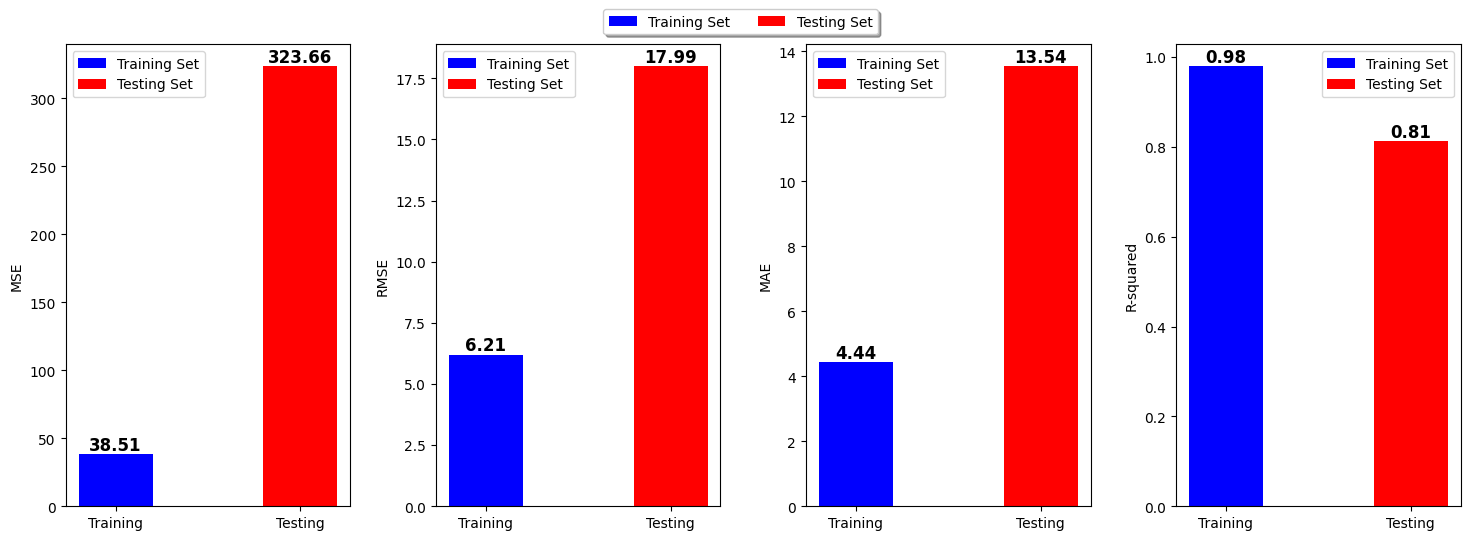

In [10]:
metrics = ['MSE', 'RMSE', 'MAE', 'R-squared']
train_metrics = [mse_train_rf_new, rmse_train_rf_new, mae_train_rf_new, r2_train_rf_new]
test_metrics = [mse_test_rf_new, rmse_test_rf_new, mae_test_rf_new, r2_test_rf_new]

fig, axes = plt.subplots(1, 4, figsize=(18, 6))

for i, (metric, train_metric, test_metric) in enumerate(zip(metrics, train_metrics, test_metrics)):
    ax = axes[i]
    ax.bar('Training', train_metric, color='b', label='Training Set', width=0.4)
    ax.bar('Testing', test_metric, color='r', label='Testing Set', width=0.4)
    ax.set_ylabel(metric)

    for bar in ax.patches:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, height, round(height, 2), 
                ha='center', va='bottom', fontsize=12, fontweight='bold')

    ax.legend()

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.95), fancybox=True, shadow=True, ncol=2)

plt.subplots_adjust(wspace=0.3)
plt.show()

#### Plot Actual vs Predicted Values

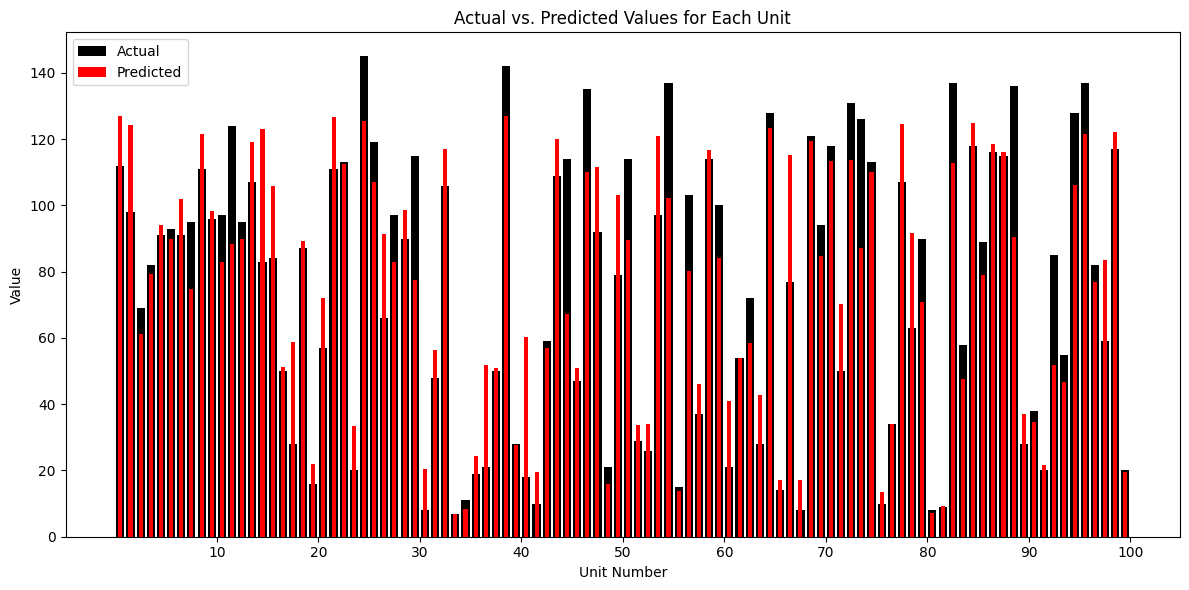

In [11]:
num_units = len(FD1_y_Test_array)
unit_numbers = np.arange(1, num_units + 1) 

actual_values = np.squeeze(FD1_y_Test_array)
predicted_values = np.squeeze(rf_new_pred_test)

fig, ax = plt.subplots(figsize=(12, 6))

bar_width = 0.8
spacing = 1

ax.bar(unit_numbers - spacing/2, actual_values, bar_width, label='Actual', color='black')
ax.bar(unit_numbers - spacing/2, predicted_values, bar_width/2, label='Predicted', color='red')

ax.set_xlabel('Unit Number')
ax.set_ylabel('Value')
ax.set_title('Actual vs. Predicted Values for Each Unit')

tick_positions = np.arange(10, num_units + 1, 10)
ax.set_xticks(tick_positions)
ax.set_xticklabels([str(int(t)) for t in tick_positions]) 

ax.legend()
plt.tight_layout()
plt.show()

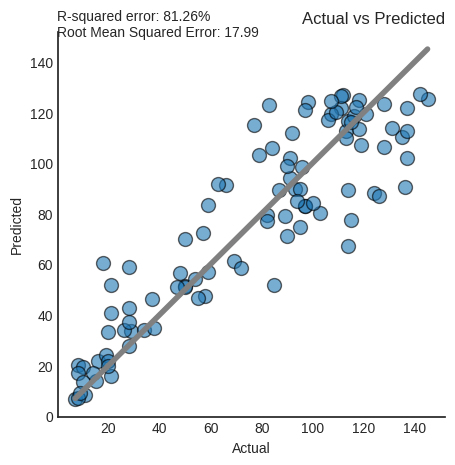

In [12]:
plt.style.use('seaborn-white')
plt.rcParams['figure.figsize']=5,5 

fig,ax = plt.subplots()
plt.title('Actual vs Predicted', loc='right')
plt.xlabel('Actual')
plt.ylabel('Predicted')
g = sns.scatterplot(x=FD1_y_Test_array,
                y=rf_new_pred_test,
                s=100,
                alpha=0.6,
                linewidth=1,
                edgecolor='black',
                ax=ax)
f = sns.lineplot(x=[min(FD1_y_Test_array),max(FD1_y_Test_array)],
             y=[min(FD1_y_Test_array),max(FD1_y_Test_array)],
             linewidth=4,
             color='gray',
             ax=ax)

plt.annotate(text=('R-squared error: '+ "{:.2%}".format(rf_new.score(FD1_X_Test,FD1_y_Test_array)) +'\n' +
                  'Root Mean Squared Error: '+ "{:.2f}".format(mean_squared_error(FD1_y_Test_array,rf_new_pred_test,squared=False))),
             xy=(0,150),
             size='medium')

xlabels = ['{:,.0f}'.format(x) for x in g.get_xticks()]
g.set_xticklabels(xlabels)
ylabels = ['{:,.0f}'.format(x) for x in g.get_yticks()]
g.set_yticklabels(ylabels)
sns.despine()